In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import joblib
from pathlib import Path

from sklearn.datasets import load_iris
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve,
)

print(f"python   {sys.version.split()[0]}")
print(f"numpy    {np.__version__}")
print(f"pandas   {pd.__version__}")
print(f"sklearn  {sklearn.__version__}")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="talk")

python   3.11.17
numpy    2.4.6
pandas   3.0.6
sklearn  1.9.1


In [2]:
iris = load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names).astype("float32")
y = pd.Series(iris.target, name="target").astype("int8")
target_names = np.array(iris.target_names)

df = X.copy()
df["target"]  = y
df["species"] = df["target"].map(dict(enumerate(target_names)))

print("Shape:", df.shape)
df.head()

Shape: (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [3]:
print(df.dtypes)
print("\nRAM, KB:", round(df.memory_usage(deep=True).sum() / 1024, 2))

sepal length (cm)    float32
sepal width (cm)     float32
petal length (cm)    float32
petal width (cm)     float32
target                  int8
species                  str
dtype: object

RAM, KB: 5.03


In [4]:
print("Пропуски:")
print(df.isna().sum())

print("\nОписательная статистика:")
df.describe().T.round(2)

Пропуски:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

Описательная статистика:


,count,mean,std,min,25%,50%,75%,max
sepal length (cm),150.0,5.84,0.83,4.3,5.1,5.80,6.4,7.9
sepal width (cm),150.0,3.06,0.44,2.0,2.8,3.00,3.3,4.4
petal length (cm),150.0,3.76,1.77,1.0,1.6,4.35,5.1,6.9
petal width (cm),150.0,1.20,0.76,0.1,0.3,1.30,1.8,2.5
target,150.0,1.00,0.82,0.0,0.0,1.00,2.0,2.0


In [5]:
counts = df["species"].value_counts()
print(counts)

imbalance_ratio = counts.max() / counts.min()
print(f"\nImbalance ratio (max/min) = {imbalance_ratio:.2f}")
print("→ Датасет сбалансирован." if imbalance_ratio < 1.5
      else "→ Есть дисбаланс, смотри не только на accuracy.")

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Imbalance ratio (max/min) = 1.00
→ Датасет сбалансирован.


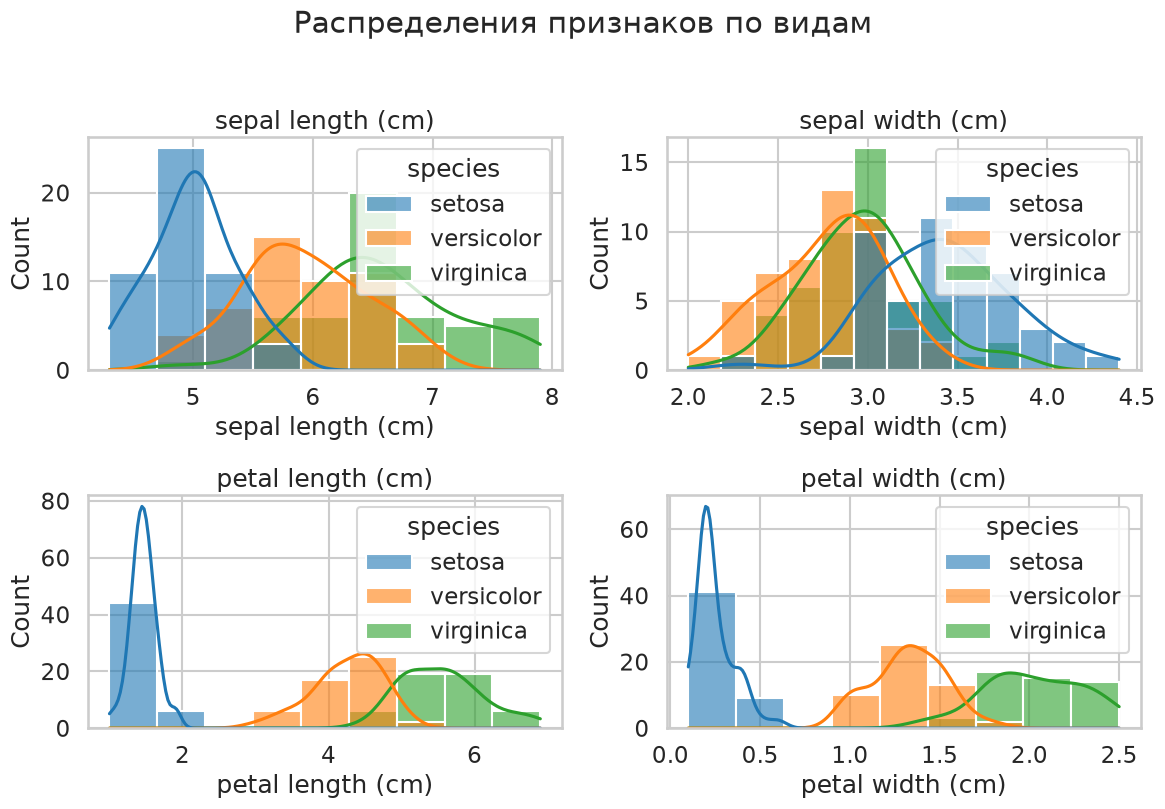

/tmp/ipykernel_49/1056055539.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="species", y=col, ax=ax, palette="tab10")
/tmp/ipykernel_49/1056055539.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="species", y=col, ax=ax, palette="tab10")
/tmp/ipykernel_49/1056055539.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="species", y=col, ax=ax, palette="tab10")
/tmp/ipykernel_49/1056055539.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. A

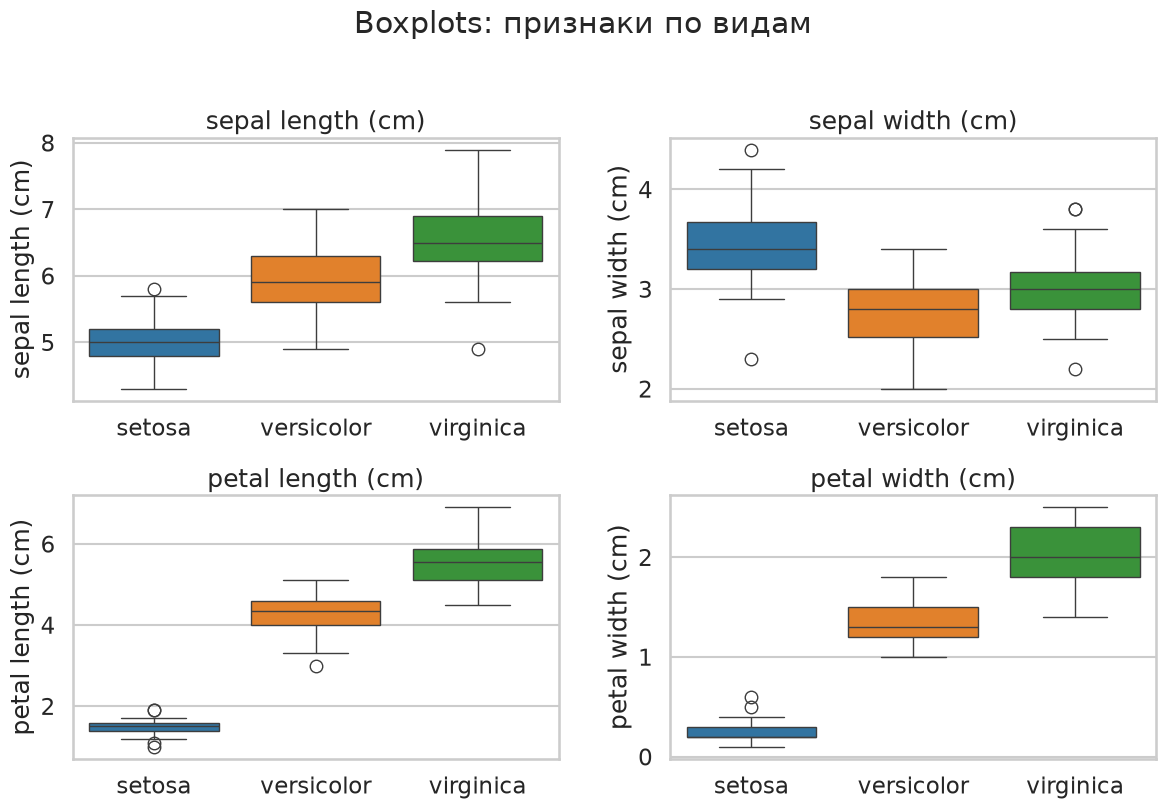

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), iris.feature_names):
    sns.histplot(data=df, x=col, hue="species",
                 kde=True, palette="tab10", ax=ax, alpha=0.6)
    ax.set_title(col)
plt.suptitle("Распределения признаков по видам", y=1.02)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), iris.feature_names):
    sns.boxplot(data=df, x="species", y=col, ax=ax, palette="tab10")
    ax.set_title(col); ax.set_xlabel("")
plt.suptitle("Boxplots: признаки по видам", y=1.02)
plt.tight_layout(); plt.show()

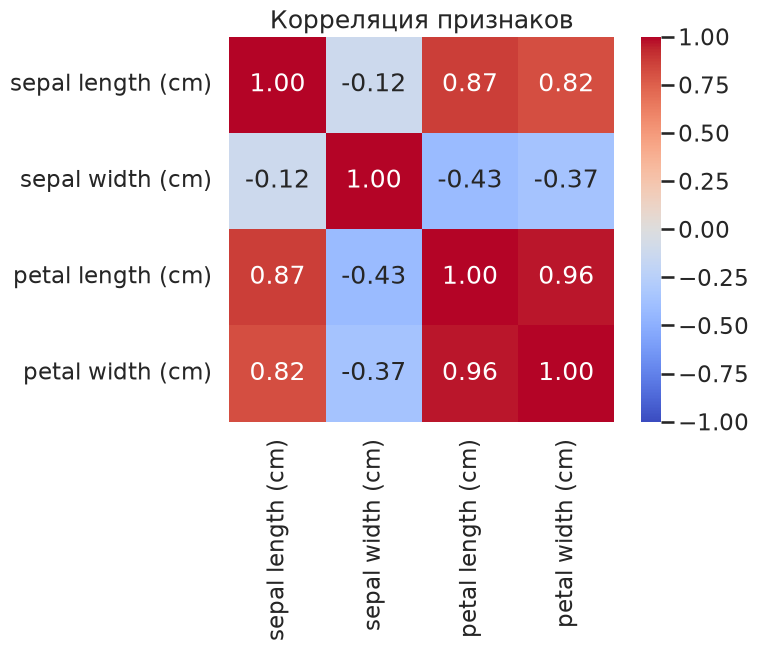

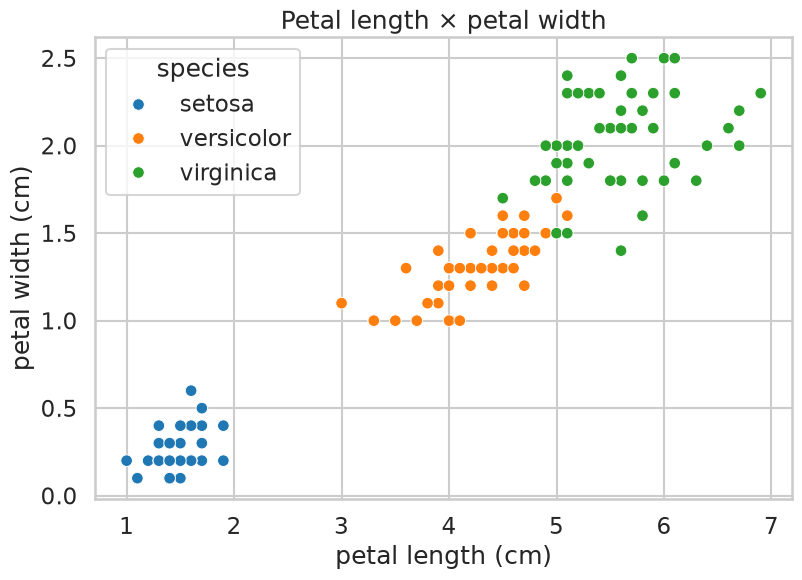

In [7]:
plt.figure(figsize=(7, 5))
corr = df[iris.feature_names].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm",
            vmin=-1, vmax=1, square=True, fmt=".2f")
plt.title("Корреляция признаков")
plt.show()

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=df, x="petal length (cm)", y="petal width (cm)",
    hue="species", palette="tab10", s=70, edgecolor="white", ax=ax
)
ax.set_title("Petal length × petal width")
plt.show()

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train classes:", np.bincount(y_train))
print("Test  classes:", np.bincount(y_test))

Train: (120, 4)  Test: (30, 4)
Train classes: [40 40 40]
Test  classes: [10 10 10]


In [9]:
models = {
    "LogReg": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    "RandomForest": RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy")
    print(f"{name:15s}  acc = {scores.mean():.4f} ± {scores.std():.4f}")

LogReg           acc = 0.9583 ± 0.0264
RandomForest     acc = 0.9500 ± 0.0312


In [10]:
best_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        C=1.0, max_iter=1000, random_state=RANDOM_STATE
    )),
])
best_model.fit(X_train, y_train)
print("Обучено:", best_model)

Обучено: Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', LogisticRegression(max_iter=1000, random_state=42))])


In [11]:
y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)   # shape (n, 3), порядок = best_model.classes_

print("classes_ (порядок вероятностей):", best_model.classes_)
print("Первые 5 предсказаний:", y_pred[:5])
print("Первые 3 строки вероятностей:")
print(pd.DataFrame(y_proba, columns=target_names).head(3).round(3))

classes_ (порядок вероятностей): [0 1 2]
Первые 5 предсказаний: [0 2 1 1 0]
Первые 3 строки вероятностей:
   setosa  versicolor  virginica
0   0.979       0.021      0.000
1   0.004       0.369      0.627
2   0.149       0.842      0.009


In [12]:
acc = accuracy_score(y_test, y_pred)
print("=" * 60)
print("📊 Accuracy = (TP + TN) / всего")
print(f"Значение: {acc:.4f}")
print("=" * 60)
print("✅ Хорошо работает при сбалансированных классах")
print("❌ Вводит в заблуждение при дисбалансе "
      "(99% accuracy при 99% нулей — бесполезно)")

📊 Accuracy = (TP + TN) / всего
Значение: 0.9333
✅ Хорошо работает при сбалансированных классах
❌ Вводит в заблуждение при дисбалансе (99% accuracy при 99% нулей — бесполезно)


In [13]:
precision_macro    = precision_score(y_test, y_pred, average="macro",    zero_division=0)
precision_weighted = precision_score(y_test, y_pred, average="weighted", zero_division=0)
precision_per_class = precision_score(y_test, y_pred, average=None, zero_division=0)

prec_df = pd.DataFrame({
    "класс": target_names,
    "precision": precision_per_class.round(3),
})
print("=" * 60)
print("🎯 Precision = TP / (TP + FP)")
print(f"macro    = {precision_macro:.4f}")
print(f"weighted = {precision_weighted:.4f}")
print("=" * 60)
print(prec_df.to_string(index=False))
print("\n✅ Критично, когда FP дорого: спам-фильтр, выдача кредита")

🎯 Precision = TP / (TP + FP)
macro    = 0.9333
weighted = 0.9333
     класс  precision
    setosa        1.0
versicolor        0.9
 virginica        0.9

✅ Критично, когда FP дорого: спам-фильтр, выдача кредита


In [14]:
recall_macro    = recall_score(y_test, y_pred, average="macro",    zero_division=0)
recall_weighted = recall_score(y_test, y_pred, average="weighted", zero_division=0)
recall_per_class = recall_score(y_test, y_pred, average=None, zero_division=0)

rec_df = pd.DataFrame({
    "класс": target_names,
    "recall": recall_per_class.round(3),
})
print("=" * 60)
print("🔍 Recall = TP / (TP + FN)")
print(f"macro    = {recall_macro:.4f}")
print(f"weighted = {recall_weighted:.4f}")
print("=" * 60)
print(rec_df.to_string(index=False))
print("\n✅ Критично, когда FN дорого: рак, фрод, утечка данных")

🔍 Recall = TP / (TP + FN)
macro    = 0.9333
weighted = 0.9333
     класс  recall
    setosa     1.0
versicolor     0.9
 virginica     0.9

✅ Критично, когда FN дорого: рак, фрод, утечка данных


In [15]:
f1_macro    = f1_score(y_test, y_pred, average="macro",    zero_division=0)
f1_weighted = f1_score(y_test, y_pred, average="weighted", zero_division=0)
f1_per_class = f1_score(y_test, y_pred, average=None, zero_division=0)

f1_df = pd.DataFrame({
    "класс":     target_names,
    "precision": precision_per_class.round(3),
    "recall":    recall_per_class.round(3),
    "f1":        f1_per_class.round(3),
})
print("=" * 60)
print("⚖️ F1 = 2 · P · R / (P + R)   — гармоническое среднее")
print(f"macro    = {f1_macro:.4f}")
print(f"weighted = {f1_weighted:.4f}")
print("=" * 60)
print(f1_df.to_string(index=False))
print("\n✅ Лучший выбор при дисбалансе классов")

⚖️ F1 = 2 · P · R / (P + R)   — гармоническое среднее
macro    = 0.9333
weighted = 0.9333
     класс  precision  recall  f1
    setosa        1.0     1.0 1.0
versicolor        0.9     0.9 0.9
 virginica        0.9     0.9 0.9

✅ Лучший выбор при дисбалансе классов


In [16]:
# Бинаризуем y_test: shape (n, 3)
y_test_bin = label_binarize(y_test, classes=best_model.classes_)

# ROC-AUC OvR для каждого класса + macro
roc_auc_per_class = roc_auc_score(y_test_bin, y_proba, average=None)
roc_auc_macro     = roc_auc_score(y_test_bin, y_proba, average="macro")
roc_auc_weighted  = roc_auc_score(y_test_bin, y_proba, average="weighted")

print("=" * 60)
print("📈 ROC-AUC — площадь под ROC-кривой (OvR для каждого класса)")
print(f"macro    = {roc_auc_macro:.4f}")
print(f"weighted = {roc_auc_weighted:.4f}")
print("=" * 60)
for name, auc in zip(target_names, roc_auc_per_class):
    print(f"  {name:12s} AUC = {auc:.4f}")
print("\n0.5 = случайное угадывание, 1.0 = идеал")
print("✅ Устойчив к дисбалансу (по сравнению с accuracy)")

📈 ROC-AUC — площадь под ROC-кривой (OvR для каждого класса)
macro    = 0.9967
weighted = 0.9967
  setosa       AUC = 1.0000
  versicolor   AUC = 0.9950
  virginica    AUC = 0.9950

0.5 = случайное угадывание, 1.0 = идеал
✅ Устойчив к дисбалансу (по сравнению с accuracy)


In [17]:
pr_auc_per_class = np.array([
    average_precision_score(y_test_bin[:, i], y_proba[:, i])
    for i in range(len(target_names))
])
pr_auc_macro = pr_auc_per_class.mean()

print("=" * 60)
print("📉 PR-AUC — площадь под Precision–Recall кривой (OvR)")
print(f"macro = {pr_auc_macro:.4f}")
print("=" * 60)
for name, ap in zip(target_names, pr_auc_per_class):
    print(f"  {name:12s} AP = {ap:.4f}")
print("\n✅ Лучшая метрика при ЭКСТРЕМАЛЬНОМ дисбалансе")
print("   (пример: 0.1% мошеннических транзакций)")

📉 PR-AUC — площадь под Precision–Recall кривой (OvR)
macro = 0.9939
  setosa       AP = 1.0000
  versicolor   AP = 0.9909
  virginica    AP = 0.9909

✅ Лучшая метрика при ЭКСТРЕМАЛЬНОМ дисбалансе
   (пример: 0.1% мошеннических транзакций)


In [18]:
summary = pd.DataFrame([
    {"Метрика": "Accuracy",  "Значение": acc,               "Формула": "(TP + TN) / всего"},
    {"Метрика": "Precision", "Значение": precision_macro,   "Формула": "TP / (TP + FP)"},
    {"Метрика": "Recall",    "Значение": recall_macro,      "Формула": "TP / (TP + FN)"},
    {"Метрика": "F1-score",  "Значение": f1_macro,          "Формула": "2·P·R / (P + R)"},
    {"Метрика": "ROC-AUC",   "Значение": roc_auc_macro,     "Формула": "площадь под ROC"},
    {"Метрика": "PR-AUC",    "Значение": pr_auc_macro,      "Формула": "площадь под PR"},
])
summary["Значение"] = summary["Значение"].round(4)
print(summary.to_string(index=False))

  Метрика  Значение           Формула
 Accuracy    0.9333 (TP + TN) / всего
Precision    0.9333    TP / (TP + FP)
   Recall    0.9333    TP / (TP + FN)
 F1-score    0.9333   2·P·R / (P + R)
  ROC-AUC    0.9967   площадь под ROC
   PR-AUC    0.9939    площадь под PR


              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        10
  versicolor      0.900     0.900     0.900        10
   virginica      0.900     0.900     0.900        10

    accuracy                          0.933        30
   macro avg      0.933     0.933     0.933        30
weighted avg      0.933     0.933     0.933        30



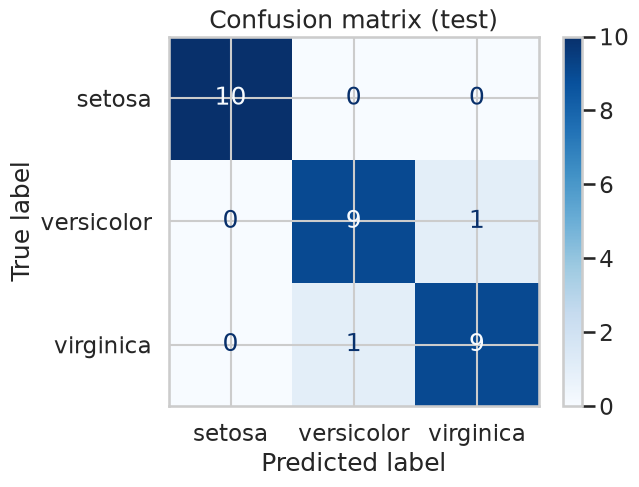

In [19]:
print(classification_report(y_test, y_pred, target_names=target_names, digits=3))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=target_names)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion matrix (test)")
plt.show()

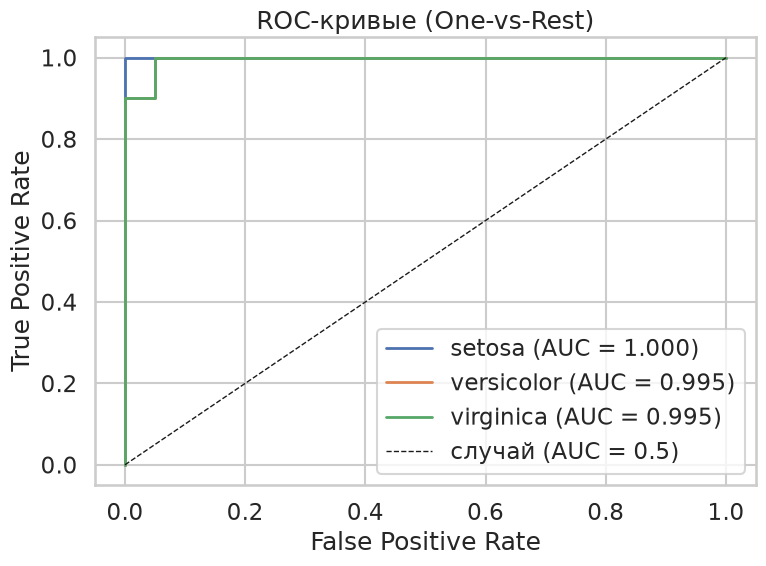

In [20]:
plt.figure(figsize=(8, 6))
for i, name in enumerate(target_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    plt.plot(fpr, tpr, lw=2,
             label=f"{name} (AUC = {roc_auc_per_class[i]:.3f})")

plt.plot([0, 1], [0, 1], "k--", lw=1, label="случай (AUC = 0.5)")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC-кривые (One-vs-Rest)")
plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

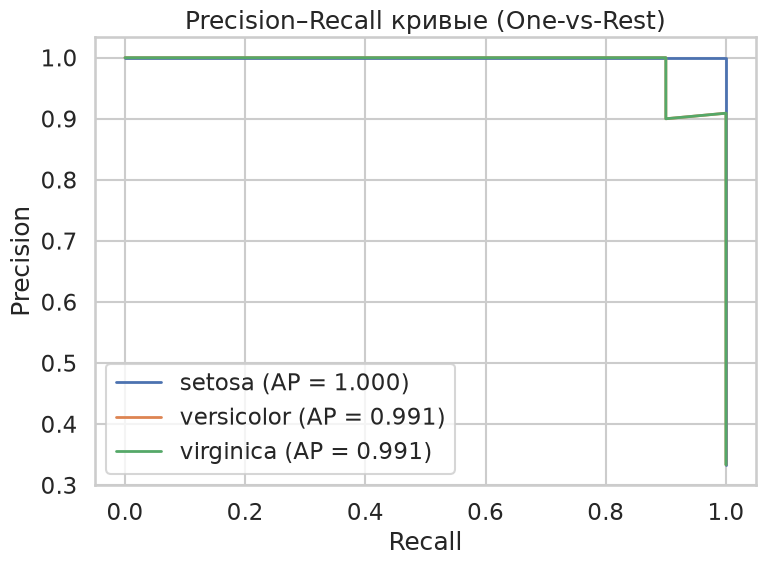

In [21]:
plt.figure(figsize=(8, 6))
for i, name in enumerate(target_names):
    p, r, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    plt.plot(r, p, lw=2,
             label=f"{name} (AP = {pr_auc_per_class[i]:.3f})")

plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision–Recall кривые (One-vs-Rest)")
plt.legend(loc="lower left"); plt.tight_layout(); plt.show()

In [22]:
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

artifact = {
    "model": best_model,
    "feature_names": list(iris.feature_names),
    "target_names":  list(target_names),
    "task": "multiclass_classification",
    "metrics": {
        "accuracy":        float(acc),
        "precision_macro": float(precision_macro),
        "recall_macro":    float(recall_macro),
        "f1_macro":        float(f1_macro),
        "roc_auc_macro":   float(roc_auc_macro),
        "pr_auc_macro":    float(pr_auc_macro),
    },
    "trained_with": {
        "python":  sys.version.split()[0],
        "numpy":   np.__version__,
        "pandas":  pd.__version__,
        "sklearn": sklearn.__version__,
    },
    "random_state": RANDOM_STATE,
}

out_path = MODEL_DIR / "iris_logreg.joblib"
joblib.dump(artifact, out_path, compress=3)
print(f"Сохранено: {out_path}  ({out_path.stat().st_size / 1024:.1f} KB)")

Сохранено: ../models/iris_logreg.joblib  (1.3 KB)


In [23]:
loaded = joblib.load(out_path)
print("Metrics:", loaded["metrics"])

test_row = pd.DataFrame([[5.1, 3.5, 1.4, 0.2]],
                        columns=loaded["feature_names"])
pred  = loaded["model"].predict(test_row)[0]
proba = loaded["model"].predict_proba(test_row)[0]
print("\nPrediction:", loaded["target_names"][pred])
print("Probabilities:",
      dict(zip(loaded["target_names"], proba.round(3))))

Metrics: {'accuracy': 0.9333333333333333, 'precision_macro': 0.9333333333333332, 'recall_macro': 0.9333333333333332, 'f1_macro': 0.9333333333333332, 'roc_auc_macro': 0.9966666666666667, 'pr_auc_macro': 0.9939393939393938}

Prediction: setosa
Probabilities: {np.str_('setosa'): np.float64(0.981), np.str_('versicolor'): np.float64(0.019), np.str_('virginica'): np.float64(0.0)}


In [24]:
from sklearn.dummy import DummyClassifier
baseline = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)
print(f"Baseline accuracy: {baseline.score(X_test, y_test):.4f}")

Baseline accuracy: 0.5000


In [25]:
errors = y_pred != y_test
X_test_df = pd.DataFrame(X_test, columns=iris.feature_names)
X_test_df["true"] = target_names[y_test]
X_test_df["pred"] = target_names[y_pred]
X_test_df["max_proba"] = y_proba.max(axis=1)
print(X_test_df[errors].round(3))

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
134                6.1               2.6                5.6               1.4   
77                 6.7               3.0                5.0               1.7   

           true        pred  max_proba  
134   virginica  versicolor      0.515  
77   versicolor   virginica      0.557  


In [26]:
coefs = pd.DataFrame(
    best_model.named_steps["clf"].coef_.T,
    index=iris.feature_names,
    columns=target_names,
)
print(coefs.round(3))

                   setosa  versicolor  virginica
sepal length (cm)  -1.089       0.536      0.553
sepal width (cm)    1.024      -0.360     -0.664
petal length (cm)  -1.799      -0.204      2.003
petal width (cm)   -1.686      -0.808      2.494


Brier score (mean OvR): 0.0283  # 0 = идеал, 0.25 = случай


ValueError: The target y is not binary. Got multiclass type of target.

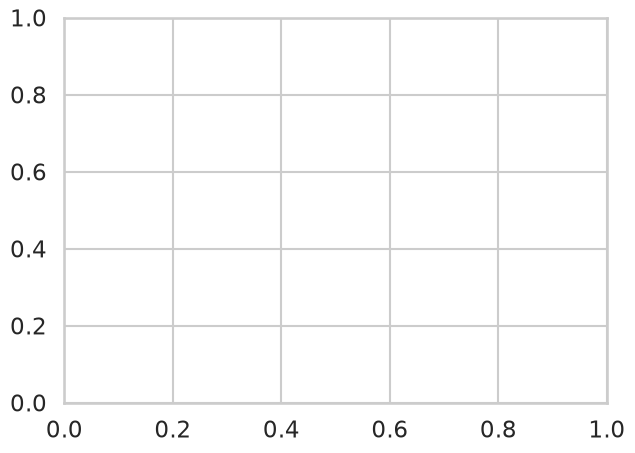

In [27]:
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt
from sklearn.calibration import CalibrationDisplay

# Brier: mean squared error между proba и one-hot true
brier = np.mean([
    brier_score_loss(y_test_bin[:, i], y_proba[:, i])
    for i in range(len(target_names))
])
print(f"Brier score (mean OvR): {brier:.4f}  # 0 = идеал, 0.25 = случай")

# Calibration curve — насколько "0.6 proba" реально означает 60% правильности
fig, ax = plt.subplots(figsize=(7, 5))
CalibrationDisplay.from_predictions(
    y_test, y_proba.argmax(axis=1),
    n_bins=5, ax=ax, name="LogReg"
)
plt.title("Калибровочная кривая (top-1)")
plt.show()

In [28]:
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold

cv_repeated = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)

param_grid = {
    "clf__C": [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
    "clf__penalty": ["l2"],
    "clf__solver": ["lbfgs"],
}
gs = GridSearchCV(
    Pipeline([("scaler", StandardScaler()),
              ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]),
    param_grid,
    cv=cv_repeated,
    scoring="f1_macro",
    n_jobs=-1,
)
gs.fit(X_train, y_train)
print("Best C:", gs.best_params_)
print(f"CV F1-macro: {gs.best_score_:.4f}")
best_model = gs.best_estimator_

/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_logi

Best C: {'clf__C': 0.5, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
CV F1-macro: 0.9579


In [29]:
from scipy.stats import ttest_rel

scores_logreg = cross_val_score(models["LogReg"], X_train, y_train,
                                cv=cv_repeated, scoring="f1_macro")
scores_rf     = cross_val_score(models["RandomForest"], X_train, y_train,
                                cv=cv_repeated, scoring="f1_macro")

t, p = ttest_rel(scores_logreg, scores_rf)
print(f"LogReg: {scores_logreg.mean():.4f} ± {scores_logreg.std():.4f}")
print(f"RF:     {scores_rf.mean():.4f} ± {scores_rf.std():.4f}")
print(f"Paired t-test: t={t:.3f}, p={p:.3f}")
print("→ Разница значима" if p < 0.05 else "→ Разница НЕ значима (бери проще)")

LogReg: 0.9579 ± 0.0309
RF:     0.9521 ± 0.0378
Paired t-test: t=1.467, p=0.164
→ Разница НЕ значима (бери проще)


In [1]:
import sys, json, hashlib
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn, joblib
from scipy.stats import ttest_rel

from sklearn.datasets import load_iris
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RepeatedStratifiedKFold,
    cross_val_score, GridSearchCV, learning_curve,
)
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve,
)

print(f"python   {sys.version.split()[0]}")
print(f"numpy    {np.__version__}")
print(f"pandas   {pd.__version__}")
print(f"sklearn  {sklearn.__version__}")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="talk")

MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

python   3.11.17
numpy    2.1.3
pandas   2.2.3
sklearn  1.5.2


In [2]:
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names).astype("float32")
y = pd.Series(iris.target, name="target").astype("int8")
target_names = np.array(iris.target_names)

df = X.copy()
df["target"] = y
df["species"] = df["target"].map(dict(enumerate(target_names)))

print("Shape:", df.shape)
print(df.dtypes)
df.head()

Shape: (150, 6)
sepal length (cm)    float32
sepal width (cm)     float32
petal length (cm)    float32
petal width (cm)     float32
target                  int8
species               object
dtype: object


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [3]:
print("Пропуски:", df.isna().sum().sum())
print("\nСтатистика:")
print(df.describe().T.round(2))

counts = df["species"].value_counts()
imbalance = counts.max() / counts.min()
print(f"\nБаланс классов: {dict(counts)}  |  imbalance ratio = {imbalance:.2f}")

Пропуски: 0

Статистика:
                   count  mean   std  min  25%   50%  75%  max
sepal length (cm)  150.0  5.84  0.83  4.3  5.1  5.80  6.4  7.9
sepal width (cm)   150.0  3.06  0.44  2.0  2.8  3.00  3.3  4.4
petal length (cm)  150.0  3.76  1.77  1.0  1.6  4.35  5.1  6.9
petal width (cm)   150.0  1.20  0.76  0.1  0.3  1.30  1.8  2.5
target             150.0  1.00  0.82  0.0  0.0  1.00  2.0  2.0

Баланс классов: {np.str_('setosa'): np.int64(50), np.str_('versicolor'): np.int64(50), np.str_('virginica'): np.int64(50)}  |  imbalance ratio = 1.00


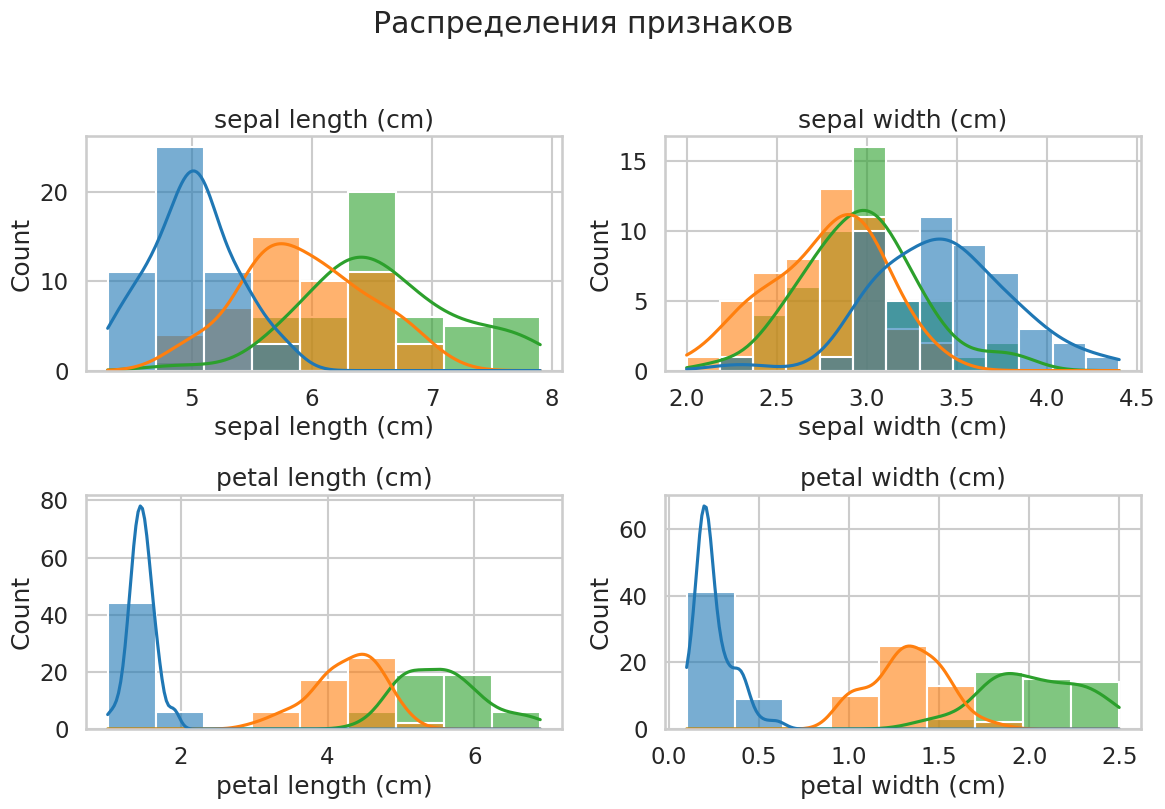

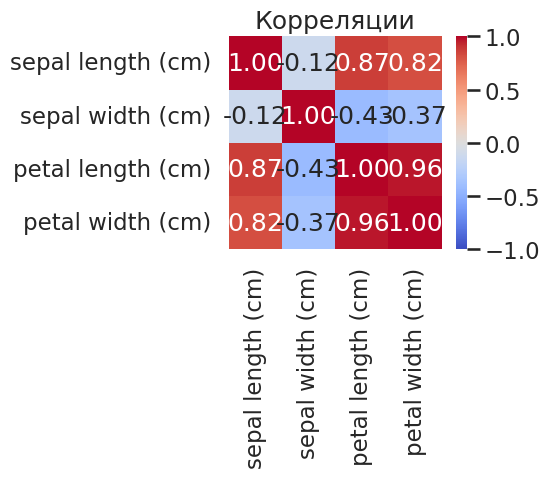

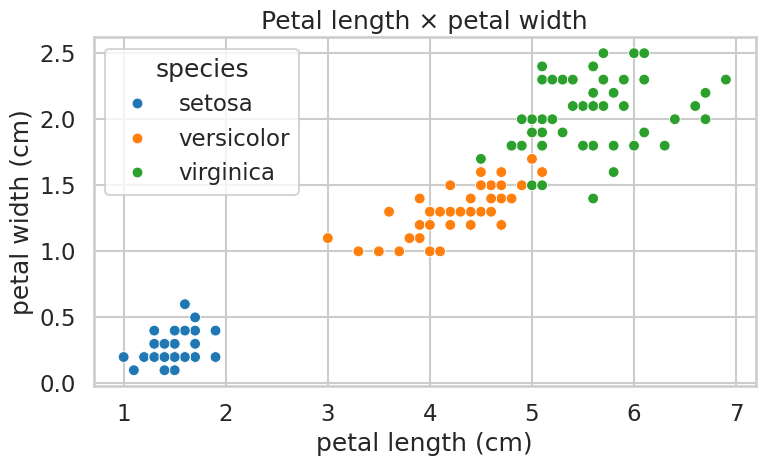

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), iris.feature_names):
    sns.histplot(data=df, x=col, hue="species", kde=True,
                 palette="tab10", ax=ax, alpha=0.6, legend=False)
    ax.set_title(col)
plt.suptitle("Распределения признаков", y=1.02)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(df[iris.feature_names].corr(), annot=True, cmap="coolwarm",
            vmin=-1, vmax=1, square=True, fmt=".2f", ax=ax)
ax.set_title("Корреляции"); plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x="petal length (cm)", y="petal width (cm)",
                hue="species", palette="tab10", s=60, edgecolor="white", ax=ax)
ax.set_title("Petal length × petal width"); plt.tight_layout(); plt.show()

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y,
)
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Train classes:", np.bincount(y_train))
print("Test  classes:", np.bincount(y_test))

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)

Train: (120, 4) | Test: (30, 4)
Train classes: [40 40 40]
Test  classes: [10 10 10]


In [6]:
baselines = {
    "most_frequent": DummyClassifier(strategy="most_frequent"),
    "stratified":    DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
}
baseline_scores = {}
for name, clf in baselines.items():
    s = cross_val_score(clf, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
    baseline_scores[name] = s.mean()
    print(f"Baseline {name:15s} acc = {s.mean():.4f} ± {s.std():.4f}")

Baseline most_frequent   acc = 0.3333 ± 0.0000
Baseline stratified      acc = 0.3000 ± 0.0509


In [7]:
candidates = {
    "LogReg": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    "RandomForest": RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)),
    ]),
}

metrics = ["accuracy", "f1_macro", "roc_auc_ovr"]
cv_results = {name: {} for name in candidates}

for name, pipe in candidates.items():
    for metric in metrics:
        s = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=metric, n_jobs=-1)
        cv_results[name][metric] = s

results_df = pd.DataFrame({
    (name, metric): [s.mean(), s.std()]
    for name, m in cv_results.items()
    for metric, s in m.items()
}, index=["mean", "std"]).T.round(4)

print(results_df)

                            mean     std
LogReg       accuracy     0.9583  0.0304
             f1_macro     0.9579  0.0309
             roc_auc_ovr  0.9983  0.0036
RandomForest accuracy     0.9528  0.0369
             f1_macro     0.9521  0.0378
             roc_auc_ovr  0.9990  0.0021
SVM          accuracy     0.9667  0.0272
             f1_macro     0.9664  0.0276
             roc_auc_ovr  0.9990  0.0028


In [8]:
def paired_ttest(a, b, label_a, label_b):
    t, p = ttest_rel(a, b)
    verdict = "ЗНАЧИМА" if p < 0.05 else "НЕ значима"
    print(f"{label_a} vs {label_b}: t={t:.3f}, p={p:.4f}  →  разница {verdict}")
    return p

print("=== Сравнение по f1_macro ===")
paired_ttest(
    cv_results["LogReg"]["f1_macro"],
    cv_results["RandomForest"]["f1_macro"],
    "LogReg", "RandomForest",
)
paired_ttest(
    cv_results["LogReg"]["f1_macro"],
    cv_results["SVM"]["f1_macro"],
    "LogReg", "SVM",
)
print("\nЕсли p > 0.05 — бери самую простую модель (LogReg).")

=== Сравнение по f1_macro ===
LogReg vs RandomForest: t=1.467, p=0.1644  →  разница НЕ значима
LogReg vs SVM: t=-1.871, p=0.0824  →  разница НЕ значима

Если p > 0.05 — бери самую простую модель (LogReg).


In [9]:
base_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

param_grid = {
    "clf__C": [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],
    "clf__penalty": ["l2"],
    "clf__solver": ["lbfgs"],
}

gs = GridSearchCV(base_pipe, param_grid, cv=cv,
                  scoring="f1_macro", n_jobs=-1)
gs.fit(X_train, y_train)

print("Best params:", gs.best_params_)
print(f"Best CV f1_macro: {gs.best_score_:.4f}")
best_model = gs.best_estimator_

Best params: {'clf__C': 0.5, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Best CV f1_macro: 0.9579


In [10]:
features_reduced = [f for f in iris.feature_names if "sepal width" not in f]
X_train_red = X_train[features_reduced]
X_test_red  = X_test[features_reduced]

pipe_red = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(C=gs.best_params_["clf__C"],
                               max_iter=1000, random_state=RANDOM_STATE)),
])
scores_red = cross_val_score(pipe_red, X_train_red, y_train,
                             cv=cv, scoring="f1_macro", n_jobs=-1)

scores_full = cross_val_score(best_model, X_train, y_train,
                              cv=cv, scoring="f1_macro", n_jobs=-1)

print(f"Full  (4 features): f1_macro = {scores_full.mean():.4f} ± {scores_full.std():.4f}")
print(f"Reduced (3 features): f1_macro = {scores_red.mean():.4f} ± {scores_red.std():.4f}")
print(f"Δ = {scores_full.mean() - scores_red.mean():+.4f}")
print("→ Фича не нужна" if abs(scores_full.mean() - scores_red.mean()) < 0.01
      else "→ Фича важна, оставляем")

Full  (4 features): f1_macro = 0.9579 ± 0.0309
Reduced (3 features): f1_macro = 0.9608 ± 0.0288
Δ = -0.0029
→ Фича не нужна


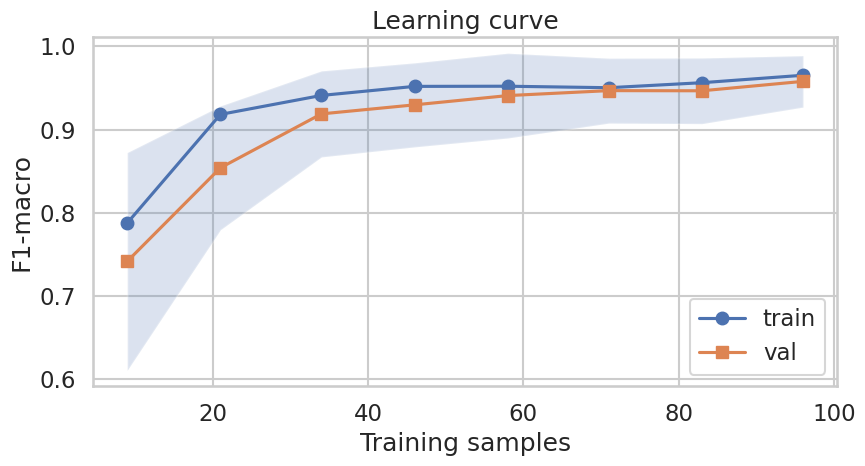

In [11]:
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=cv, scoring="f1_macro", n_jobs=-1,
)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), "o-", label="train")
plt.plot(train_sizes, val_scores.mean(axis=1), "s-", label="val")
plt.fill_between(train_sizes,
                 val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1),
                 alpha=0.2)
plt.xlabel("Training samples"); plt.ylabel("F1-macro")
plt.title("Learning curve"); plt.legend(); plt.tight_layout(); plt.show()

In [12]:
voter = VotingClassifier(
    estimators=[
        ("lr", Pipeline([("sc", StandardScaler()),
                         ("clf", LogisticRegression(C=gs.best_params_["clf__C"],
                                                    max_iter=1000,
                                                    random_state=RANDOM_STATE))])),
        ("rf", RandomForestClassifier(n_estimators=300,
                                       random_state=RANDOM_STATE, n_jobs=-1)),
        ("svc", Pipeline([("sc", StandardScaler()),
                          ("clf", SVC(kernel="rbf", probability=True,
                                      random_state=RANDOM_STATE))])),
    ],
    voting="soft",
)
voter_scores = cross_val_score(voter, X_train, y_train,
                               cv=cv, scoring="f1_macro", n_jobs=-1)

print(f"LogReg alone:   f1_macro = {scores_full.mean():.4f} ± {scores_full.std():.4f}")
print(f"Voting (soft):  f1_macro = {voter_scores.mean():.4f} ± {voter_scores.std():.4f}")
print(f"Δ = {voter_scores.mean() - scores_full.mean():+.4f}")
print("→ Ансамбль не нужен" if voter_scores.mean() - scores_full.mean() < 0.015
      else "→ Ансамбль даёт выигрыш")

LogReg alone:   f1_macro = 0.9579 ± 0.0309
Voting (soft):  f1_macro = 0.9579 ± 0.0309
Δ = +0.0000
→ Ансамбль не нужен


In [13]:
best_model.fit(X_train, y_train)
y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)
y_test_bin = label_binarize(y_test, classes=best_model.classes_)

print("classes_:", best_model.classes_)
print("Первые 5 предсказаний:", y_pred[:5])

classes_: [0 1 2]
Первые 5 предсказаний: [0 2 1 1 0]


In [14]:
acc = accuracy_score(y_test, y_pred)
precision_macro    = precision_score(y_test, y_pred, average="macro",    zero_division=0)
recall_macro       = recall_score(y_test, y_pred,    average="macro",    zero_division=0)
f1_macro           = f1_score(y_test, y_pred,        average="macro",    zero_division=0)
roc_auc_macro      = roc_auc_score(y_test_bin, y_proba, average="macro")
pr_auc_macro       = np.mean([
    average_precision_score(y_test_bin[:, i], y_proba[:, i])
    for i in range(len(target_names))
])
brier_macro = np.mean([
    brier_score_loss(y_test_bin[:, i], y_proba[:, i])
    for i in range(len(target_names))
])

summary = pd.DataFrame([
    {"Метрика": "Accuracy",  "Значение": round(acc, 4),            "Формула": "(TP+TN)/всего"},
    {"Метрика": "Precision", "Значение": round(precision_macro, 4), "Формула": "TP/(TP+FP)"},
    {"Метрика": "Recall",    "Значение": round(recall_macro, 4),    "Формула": "TP/(TP+FN)"},
    {"Метрика": "F1-score",  "Значение": round(f1_macro, 4),        "Формула": "2PR/(P+R)"},
    {"Метрика": "ROC-AUC",   "Значение": round(roc_auc_macro, 4),   "Формула": "площадь под ROC"},
    {"Метрика": "PR-AUC",    "Значение": round(pr_auc_macro, 4),    "Формула": "площадь под PR"},
    {"Метрика": "Brier",     "Значение": round(brier_macro, 4),     "Формула": "MSE(proba, one-hot)"},
])
print(summary.to_string(index=False))
print(f"\nBaseline (most_frequent): {baseline_scores['most_frequent']:.4f}")
print(f"Выигрыш над baseline:      {acc - baseline_scores['most_frequent']:+.4f}")

  Метрика  Значение             Формула
 Accuracy    0.9333       (TP+TN)/всего
Precision    0.9333          TP/(TP+FP)
   Recall    0.9333          TP/(TP+FN)
 F1-score    0.9333           2PR/(P+R)
  ROC-AUC    0.9967     площадь под ROC
   PR-AUC    0.9939      площадь под PR
    Brier    0.0374 MSE(proba, one-hot)

Baseline (most_frequent): 0.3333
Выигрыш над baseline:      +0.6000


              precision    recall  f1-score   support

      setosa      1.000     1.000     1.000        10
  versicolor      0.900     0.900     0.900        10
   virginica      0.900     0.900     0.900        10

    accuracy                          0.933        30
   macro avg      0.933     0.933     0.933        30
weighted avg      0.933     0.933     0.933        30



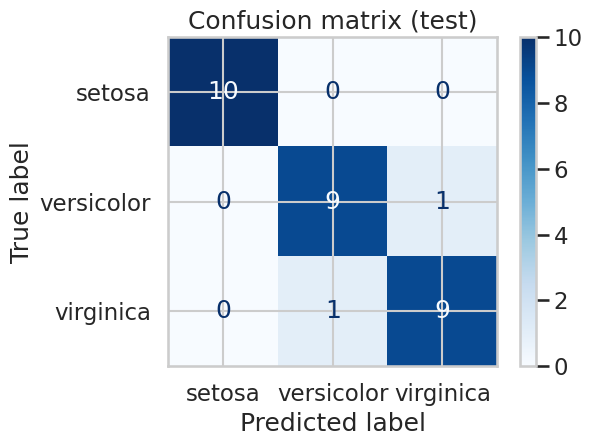

In [15]:
print(classification_report(y_test, y_pred, target_names=target_names, digits=3))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=target_names).plot(cmap="Blues", values_format="d")
plt.title("Confusion matrix (test)"); plt.tight_layout(); plt.show()

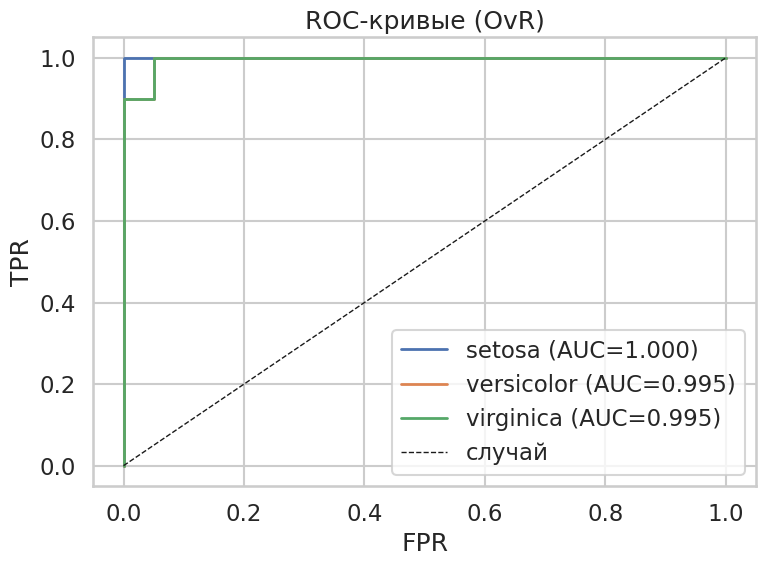

In [16]:
plt.figure(figsize=(8, 6))
for i, name in enumerate(target_names):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    auc_i = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc_i:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="случай")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC-кривые (OvR)")
plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

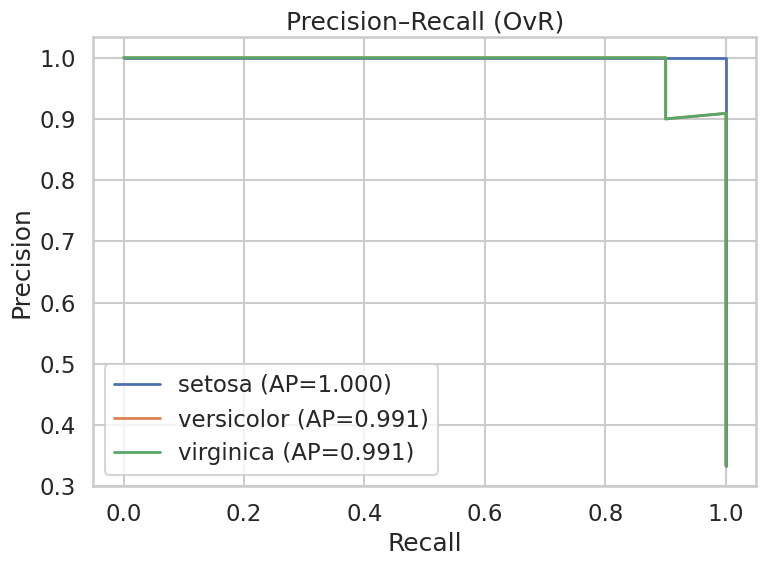

In [17]:
plt.figure(figsize=(8, 6))
for i, name in enumerate(target_names):
    p, r, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    ap = average_precision_score(y_test_bin[:, i], y_proba[:, i])
    plt.plot(r, p, lw=2, label=f"{name} (AP={ap:.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision–Recall (OvR)")
plt.legend(loc="lower left"); plt.tight_layout(); plt.show()

In [19]:
errors = y_pred != y_test
X_test_df = X_test.copy()
X_test_df["true"] = target_names[y_test]
X_test_df["pred"] = target_names[y_pred]
X_test_df["max_proba"] = y_proba.max(axis=1).round(3)

print(f"Ошибок: {errors.sum()} из {len(y_test)}")
print("\nОшибочные примеры:")
print(X_test_df[errors].to_string())

print("\nТоп-5 неуверенных предсказаний (max_proba близко к 0.5):")
print(X_test_df.reindex(X_test_df["max_proba"].sub(0.5).abs().sort_values().index).head())

Ошибок: 2 из 30

Ошибочные примеры:
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)        true        pred  max_proba
134                6.1               2.6                5.6               1.4   virginica  versicolor      0.552
77                 6.7               3.0                5.0               1.7  versicolor   virginica      0.570

Топ-5 неуверенных предсказаний (max_proba близко к 0.5):
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
134                6.1               2.6                5.6               1.4   
77                 6.7               3.0                5.0               1.7   
138                6.0               3.0                4.8               1.8   
56                 6.3               3.3                4.7               1.6   
127                6.1               3.0                4.9               1.8   

           true        pred  max_proba  
134   virginica  versicolor      0.552 

In [20]:
class IrisPredictor:
    """Обёртка: валидация схемы, диапазонов, NaN и предсказание."""
    REQUIRED = ["sepal length (cm)", "sepal width (cm)",
                "petal length (cm)", "petal width (cm)"]

    def __init__(self, artifact: dict):
        self.model = artifact["model"]
        self.feature_names = artifact["feature_names"]
        self.target_names = artifact["target_names"]
        self.feature_ranges = artifact["feature_ranges"]

    def predict(self, X: pd.DataFrame) -> list[str]:
        missing = set(self.REQUIRED) - set(X.columns)
        if missing:
            raise ValueError(f"Отсутствуют признаки: {missing}")
        X = X[self.feature_names].astype("float32")
        if X.isna().any().any():
            raise ValueError("Входные данные содержат NaN")
        for col, (lo, hi) in self.feature_ranges.items():
            if (X[col] < lo).any() or (X[col] > hi).any():
                bad = X[(X[col] < lo) | (X[col] > hi)][col].tolist()
                raise ValueError(f"{col}: значения {bad} вне диапазона [{lo:.2f}, {hi:.2f}]")
        idx = self.model.predict(X)
        return [self.target_names[i] for i in idx]

    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        X = X[self.feature_names].astype("float32")
        return self.model.predict_proba(X)

print("Wrapper class готов.")

Wrapper class готов.


In [21]:
stamp = datetime.now().strftime("%Y%m%d_%H%M")

# Диапазоны фич на train (для валидации входа)
feature_ranges = {
    col: [float(X_train[col].min()), float(X_train[col].max())]
    for col in iris.feature_names
}

# CV-метрики (надёжнее одного прогона)
cv_metrics = {}
for metric in ["accuracy", "f1_macro", "roc_auc_ovr"]:
    s = cross_val_score(best_model, X_train, y_train, cv=cv, scoring=metric, n_jobs=-1)
    cv_metrics[metric] = {"mean": round(float(s.mean()), 4),
                          "std":  round(float(s.std()), 4)}

artifact = {
    "schema_version": "1.0",
    "task": "multiclass_classification",
    "model_name": "iris_logreg",
    "trained_at": stamp,
    "random_state": RANDOM_STATE,

    "model": best_model,

    "feature_names": list(iris.feature_names),
    "target_names":  list(target_names),
    "feature_ranges": feature_ranges,
    "dtypes": {col: "float32" for col in iris.feature_names},

    "cv_metrics": cv_metrics,
    "cv_strategy": "RepeatedStratifiedKFold(n_splits=5, n_repeats=3)",

    "test_metrics": {
        "accuracy":        round(float(acc), 4),
        "precision_macro": round(float(precision_macro), 4),
        "recall_macro":    round(float(recall_macro), 4),
        "f1_macro":        round(float(f1_macro), 4),
        "roc_auc_macro":   round(float(roc_auc_macro), 4),
        "pr_auc_macro":    round(float(pr_auc_macro), 4),
        "brier_macro":     round(float(brier_macro), 4),
    },
    "test_size": int(len(y_test)),

    "baseline": {
        "most_frequent": round(float(baseline_scores["most_frequent"]), 4),
        "stratified":    round(float(baseline_scores["stratified"]), 4),
    },

    "best_params": gs.best_params_,

    "trained_with": {
        "python":  sys.version.split()[0],
        "numpy":   np.__version__,
        "pandas":  pd.__version__,
        "sklearn": sklearn.__version__,
    },
}

out_path = MODEL_DIR / f"iris_logreg_{stamp}.joblib"
joblib.dump(artifact, out_path, compress=3)

card_path = MODEL_DIR / f"iris_logreg_{stamp}.json"
card = {
    "name": artifact["model_name"],
    "trained_at": stamp,
    "baseline": artifact["baseline"],
    "cv_metrics": artifact["cv_metrics"],
    "test_metrics": artifact["test_metrics"],
    "features": artifact["feature_names"],
    "classes": artifact["target_names"],
}
with open(card_path, "w", encoding="utf-8") as f:
    json.dump(card, f, indent=2, ensure_ascii=False)

print(f"Модель:      {out_path}  ({out_path.stat().st_size/1024:.1f} KB)")
print(f"Model card:  {card_path}")

Модель:      ../models/iris_logreg_20261002_1104.joblib  (1.8 KB)
Model card:  ../models/iris_logreg_20261002_1104.json


In [22]:
loaded = joblib.load(out_path)
predictor = IrisPredictor(loaded)

print("Метрики из артефакта:", loaded["test_metrics"])
print()

# 1) Штатное предсказание
sample = pd.DataFrame([[5.1, 3.5, 1.4, 0.2]], columns=loaded["feature_names"])
print("Штатный вход:", predictor.predict(sample))

# 2) Отсутствует признак
try:
    predictor.predict(sample.drop(columns=["petal width (cm)"]))
except ValueError as e:
    print("Пропущен признак → ValueError:", e)

# 3) NaN во входе
try:
    predictor.predict(pd.DataFrame([[5.1, 3.5, np.nan, 0.2]], columns=loaded["feature_names"]))
except ValueError as e:
    print("NaN во входе → ValueError:", e)

# 4) Значение вне обучающего диапазона
try:
    predictor.predict(pd.DataFrame([[5.1, 3.5, 1.4, 100.0]], columns=loaded["feature_names"]))
except ValueError as e:
    print("Вне диапазона → ValueError:", e)

Метрики из артефакта: {'accuracy': 0.9333, 'precision_macro': 0.9333, 'recall_macro': 0.9333, 'f1_macro': 0.9333, 'roc_auc_macro': 0.9967, 'pr_auc_macro': 0.9939, 'brier_macro': 0.0374}

Штатный вход: [np.str_('setosa')]
Пропущен признак → ValueError: Отсутствуют признаки: {'petal width (cm)'}
NaN во входе → ValueError: Входные данные содержат NaN
Вне диапазона → ValueError: petal width (cm): значения [100.0] вне диапазона [0.10, 2.50]


Brier score (mean OvR): 0.0374  # 0 = идеал, 0.25 = случай


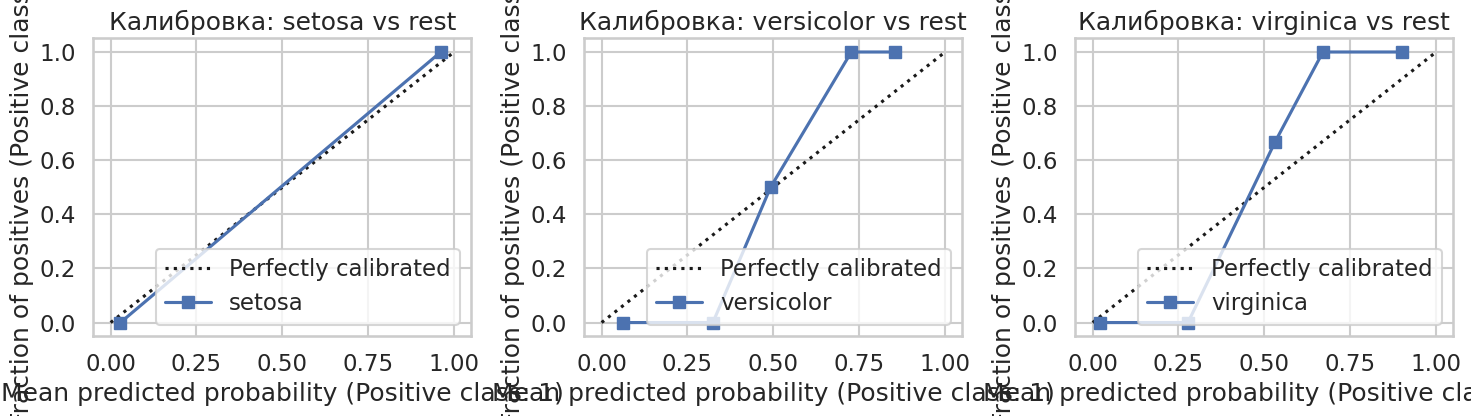

In [23]:
from sklearn.metrics import brier_score_loss
from sklearn.calibration import CalibrationDisplay
import matplotlib.pyplot as plt

# --- Brier score (OvR, усреднение по классам) ---
brier = np.mean([
    brier_score_loss(y_test_bin[:, i], y_proba[:, i])
    for i in range(len(target_names))
])
print(f"Brier score (mean OvR): {brier:.4f}  # 0 = идеал, 0.25 = случай")

# --- Calibration curves: по одному графику на класс (OvR) ---
fig, axes = plt.subplots(1, len(target_names), figsize=(5 * len(target_names), 4.5))
for i, (name, ax) in enumerate(zip(target_names, axes)):
    CalibrationDisplay.from_predictions(
        y_test_bin[:, i], y_proba[:, i],
        n_bins=5, ax=ax, name=str(name),
    )
    ax.set_title(f"Калибровка: {name} vs rest")
plt.tight_layout()
plt.show()

[1] Best C=0.5, CV f1_macro=0.9579
[2] full=0.9579  red=0.9608  Wilcoxon p=0.3173 → НЕ значимо, оставляем 4 фичи
[3] LogReg=0.9579  Voting=0.9579  t-test p=nan → ансамбль не нужен
[4] Brier score (mean OvR) = 0.0374


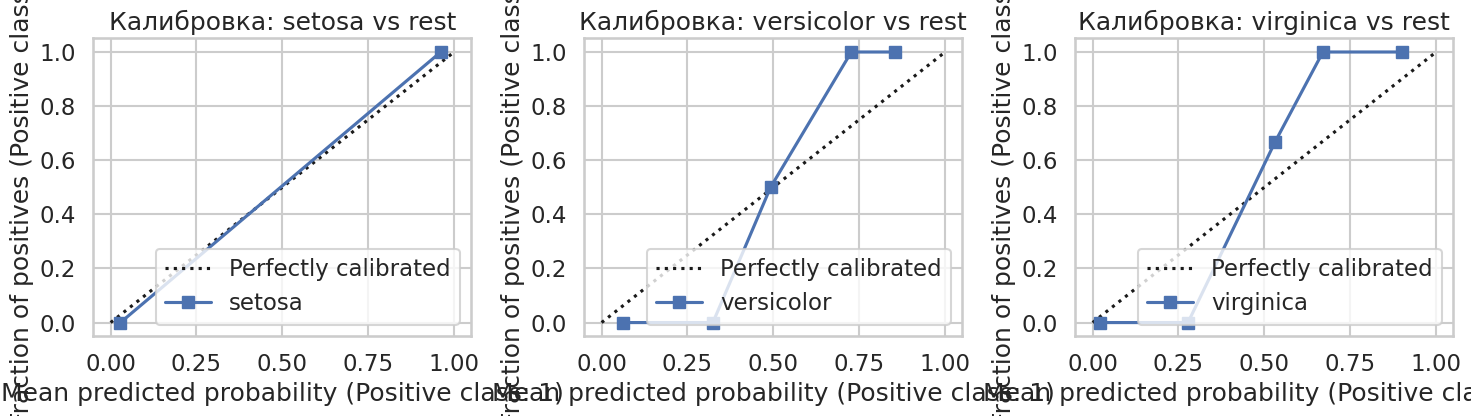


✅ All fixes applied. Now: Restart & Run All for reproducibility.


In [24]:
# === ALL FIXES IN ONE CELL ===
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from scipy.stats import wilcoxon, ttest_rel
import matplotlib.pyplot as plt

# 1) Re-fit GridSearch WITHOUT deprecated penalty
gs = GridSearchCV(
    Pipeline([("scaler", StandardScaler()),
              ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]),
    {"clf__C": [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]},
    cv=cv, scoring="f1_macro", n_jobs=-1,
).fit(X_train, y_train)
best_model = gs.best_estimator_
print(f"[1] Best C={gs.best_params_['clf__C']}, CV f1_macro={gs.best_score_:.4f}")

y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)

# 2) Feature selection with Wilcoxon
feats_red = [f for f in iris.feature_names if "sepal width" not in f]
pipe_red  = Pipeline([("sc", StandardScaler()),
                      ("clf", LogisticRegression(C=gs.best_params_["clf__C"],
                                                 max_iter=1000, random_state=RANDOM_STATE))])
s_full = cross_val_score(best_model, X_train, y_train,            cv=cv, scoring="f1_macro", n_jobs=-1)
s_red  = cross_val_score(pipe_red,  X_train[feats_red], y_train,  cv=cv, scoring="f1_macro", n_jobs=-1)
p_fs = wilcoxon(s_full, s_red).pvalue
print(f"[2] full={s_full.mean():.4f}  red={s_red.mean():.4f}  Wilcoxon p={p_fs:.4f} "
      f"→ {'значимо' if p_fs<0.05 else 'НЕ значимо, оставляем 4 фичи'}")

# 3) Voting vs plain LogReg — paired test on same folds
voter = VotingClassifier(
    estimators=[
        ("lr",  Pipeline([("sc", StandardScaler()),
                          ("clf", LogisticRegression(C=gs.best_params_["clf__C"],
                                                     max_iter=1000, random_state=RANDOM_STATE))])),
        ("rf",  RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)),
        ("svc", Pipeline([("sc", StandardScaler()),
                          ("clf", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))])),
    ],
    voting="soft",
)
s_vote = cross_val_score(voter, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)
p_vote = ttest_rel(s_vote, s_full).pvalue
print(f"[3] LogReg={s_full.mean():.4f}  Voting={s_vote.mean():.4f}  "
      f"t-test p={p_vote:.4f} → {'ансамбль оправдан' if p_vote<0.05 else 'ансамбль не нужен'}")

# 4) Correct calibration: OvR per class
y_test_bin = label_binarize(y_test, classes=best_model.classes_)
brier = np.mean([brier_score_loss(y_test_bin[:, i], y_proba[:, i])
                 for i in range(len(target_names))])
print(f"[4] Brier score (mean OvR) = {brier:.4f}")

fig, axes = plt.subplots(1, len(target_names), figsize=(5*len(target_names), 4.5))
for i, (name, ax) in enumerate(zip(target_names, axes)):
    CalibrationDisplay.from_predictions(
        y_test_bin[:, i], y_proba[:, i], n_bins=5, ax=ax, name=str(name))
    ax.set_title(f"Калибровка: {name} vs rest")
plt.tight_layout(); plt.show()

print("\n✅ All fixes applied. Now: Restart & Run All for reproducibility.")